In [1]:
import sys
import time
import warnings
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error

import pymc as pm
import arviz as az

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)


c:\Users\Alejandro\anaconda3\envs\policeproj\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "src" / "cbl20").exists():
            return candidate
    raise FileNotFoundError(f"Could not find project root containing src/cbl20 from: {start}")

PROJECT_ROOT = find_project_root(Path.cwd())
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from cbl20.spatial_adjacency import (
    load_lsoa_centroids,
    validate_lsoa_code_coverage,
    build_knn_adjacency_from_centroids,
    summarize_adjacency,
    add_neighbour_previous_month_feature,
)

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
SPATIAL_DIR = DATA_DIR / "spatial"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
TABLES_DIR = OUTPUT_DIR / "tables"

TABLES_DIR.mkdir(parents=True, exist_ok=True)

CRIME_PARQUET_PATH = PROCESSED_DIR / "crimes_filtered_for_model.parquet"
if not CRIME_PARQUET_PATH.exists():
    CRIME_PARQUET_PATH = PROCESSED_DIR / "crimes_clean_dedup_all_years.parquet"

LSOA_CENTROID_CSV = (
    SPATIAL_DIR
    / "Lower_layer_Super_Output_Areas_December_2021_Boundaries_EW_BGC_V5_4163309575471683775.csv"
)

print("Project root:", PROJECT_ROOT)
print("Crime parquet:", CRIME_PARQUET_PATH, CRIME_PARQUET_PATH.exists())
print("LSOA centroid CSV:", LSOA_CENTROID_CSV, LSOA_CENTROID_CSV.exists())


Project root: C:\Users\Alejandro\Desktop\Uni Files\cbl_crime\cbl_20
Crime parquet: C:\Users\Alejandro\Desktop\Uni Files\cbl_crime\cbl_20\data\processed\crimes_filtered_for_model.parquet True
LSOA centroid CSV: C:\Users\Alejandro\Desktop\Uni Files\cbl_crime\cbl_20\data\spatial\Lower_layer_Super_Output_Areas_December_2021_Boundaries_EW_BGC_V5_4163309575471683775.csv True


In [3]:
SELECTED_POLICE_FORCES = [
    "Cheshire Constabulary",
    "Lincolnshire Police",
    "Merseyside Police",
    "Metropolitan Police Service",
    "West Midlands Police",
]

SELECTED_CRIME_TYPES = [
    "Anti-social behaviour",
    "Criminal damage and arson",
    "Drugs",
    "Possession of weapons",
    "Vehicle crime",
]

EXPERIMENTS = [
    {
        "experiment_id": "pre_pandemic",
        "description": "Pre-pandemic regime",
        "train_windows": [("2012-01", "2018-12")],
        "test_window": ("2019-01", "2019-12"),
        "is_operational_forecast": False,
    },
    {
        "experiment_id": "post_pandemic",
        "description": "Post-pandemic regime",
        "train_windows": [("2022-01", "2023-12")],
        "test_window": ("2024-01", "2024-12"),
        "is_operational_forecast": False,
    },
    {
        "experiment_id": "combined_non_pandemic",
        "description": "Combined non-pandemic regime",
        "train_windows": [("2012-01", "2019-12"), ("2022-01", "2024-12")],
        "test_window": ("2025-01", "2025-12"),
        "is_operational_forecast": False,
    },
    {
        "experiment_id": "operational_forecast",
        "description": "Final operational forecasting",
        "train_windows": "all_available",
        "test_window": "next_12_months",
        "is_operational_forecast": True,
    },
]

EXPERIMENTS_TO_RUN = "all"

MAX_LSOAS_PER_MODEL = 100
MIN_TOTAL_CRIMES_PER_LSOA = 1
MIN_CENTROID_COVERAGE = 0.80
ADJACENCY_K_NEIGHBOURS = 5

DRAWS = 300
TUNE = 300
CHAINS = 2
TARGET_ACCEPT = 0.9
RANDOM_SEED = 42

SAVE_RESULTS = True
OUTPUT_TAG = "shared_regime_comparison_bayesian_adj_no_offset"

print("Selected forces:", len(SELECTED_POLICE_FORCES))
print("Selected crime types:", len(SELECTED_CRIME_TYPES))
print("Total force-crime combinations:", len(SELECTED_POLICE_FORCES) * len(SELECTED_CRIME_TYPES))
print("Experiments:", [e["experiment_id"] for e in EXPERIMENTS])


Selected forces: 5
Selected crime types: 5
Total force-crime combinations: 25
Experiments: ['pre_pandemic', 'post_pandemic', 'combined_non_pandemic', 'operational_forecast']


In [4]:
lsoa_centroids = load_lsoa_centroids(LSOA_CENTROID_CSV)

data_months = duckdb.sql(f'''
    SELECT
        MIN("Month") AS min_month,
        MAX("Month") AS max_month,
        COUNT(*) AS n_rows
    FROM read_parquet('{CRIME_PARQUET_PATH.as_posix()}')
''').df()

DATA_MIN_MONTH = str(data_months.loc[0, "min_month"])
DATA_MAX_MONTH = str(data_months.loc[0, "max_month"])

print(data_months)
print("Centroid LSOAs:", lsoa_centroids["lsoa_code"].nunique())


  min_month max_month    n_rows
0   2012-01   2026-03  57030272
Centroid LSOAs: 35672


In [5]:
def to_month_start(value: str) -> pd.Timestamp:
    return pd.to_datetime(value, format="%Y-%m")

def month_str(value: pd.Timestamp) -> str:
    return pd.Timestamp(value).strftime("%Y-%m")

def next_month(value: str) -> str:
    return month_str(to_month_start(value) + pd.DateOffset(months=1))

def add_months(value: str, n: int) -> str:
    return month_str(to_month_start(value) + pd.DateOffset(months=n))

def resolve_experiment_windows(experiment: dict) -> dict:
    exp = experiment.copy()
    if exp["train_windows"] == "all_available":
        train_start = DATA_MIN_MONTH
        train_end = DATA_MAX_MONTH
        test_start = next_month(DATA_MAX_MONTH)
        test_end = add_months(test_start, 11)
        exp["train_windows"] = [(train_start, train_end)]
        exp["test_window"] = (test_start, test_end)
    return exp

def windows_to_mask(month_series: pd.Series, windows: list[tuple[str, str]]) -> pd.Series:
    mask = pd.Series(False, index=month_series.index)
    for start, end in windows:
        start_ts = to_month_start(start)
        end_ts = to_month_start(end)
        mask = mask | ((month_series >= start_ts) & (month_series <= end_ts))
    return mask

def experiment_panel_bounds(experiment: dict) -> tuple[str, str]:
    train_windows = experiment["train_windows"]
    test_start, test_end = experiment["test_window"]
    starts = [start for start, _ in train_windows] + [test_start]
    ends = [end for _, end in train_windows] + [test_end]
    return min(starts), max(ends)

def sql_in_list(values: list[str]) -> str:
    return ", ".join("'" + v.replace("'", "''") + "'" for v in values)


In [6]:
def check_selected_sample_availability():
    force_sql = sql_in_list(SELECTED_POLICE_FORCES)
    crime_sql = sql_in_list(SELECTED_CRIME_TYPES)
    out = duckdb.sql(f'''
        SELECT
            "Falls within" AS police_force,
            "Crime type" AS crime_type,
            MIN("Month") AS min_month,
            MAX("Month") AS max_month,
            COUNT(*) AS n_records,
            COUNT(DISTINCT "LSOA code") AS n_lsoas
        FROM read_parquet('{CRIME_PARQUET_PATH.as_posix()}')
        WHERE "Falls within" IN ({force_sql})
          AND "Crime type" IN ({crime_sql})
          AND "LSOA code" IS NOT NULL
        GROUP BY "Falls within", "Crime type"
        ORDER BY "Falls within", "Crime type"
    ''').df()
    return out

availability = check_selected_sample_availability()
display(availability)
print("Expected force-crime rows:", len(SELECTED_POLICE_FORCES) * len(SELECTED_CRIME_TYPES))
print("Available force-crime rows:", len(availability))


,police_force,crime_type,min_month,max_month,n_records,n_lsoas
0,Cheshire Constabulary,Anti-social behaviour,2012-01,2026-03,234413,983
1,Cheshire Constabulary,Criminal damage and arson,2012-01,2026-03,88285,735
2,Cheshire Constabulary,Drugs,2012-01,2026-03,24796,719
3,Cheshire Constabulary,Possession of weapons,2013-05,2026-03,5252,640
4,Cheshire Constabulary,Vehicle crime,2012-01,2026-03,40476,732
5,Lincolnshire Police,Anti-social behaviour,2012-01,2026-03,170069,482
6,Lincolnshire Police,Criminal damage and arson,2012-01,2026-03,66503,479
7,Lincolnshire Police,Drugs,2012-01,2026-03,17438,468
8,Lincolnshire Police,Possession of weapons,2013-05,2026-03,5099,433
9,Lincolnshire Police,Vehicle crime,2012-01,2026-03,33802,480


Expected force-crime rows: 25
Available force-crime rows: 25


In [7]:
def build_lsoa_month_panel(
    parquet_path: Path,
    police_force: str,
    crime_type: str,
    panel_start_month: str,
    panel_end_month: str,
    train_windows: list[tuple[str, str]],
    lsoa_reference: pd.DataFrame,
    max_lsoas: int | None = 100,
    min_total_crimes: int = 1,
    min_centroid_coverage: float = 0.80,
) -> tuple[pd.DataFrame, dict]:
    parquet_path_posix = Path(parquet_path).as_posix()

    train_filter = " OR ".join(
        [f'("Month" BETWEEN \'{start}\' AND \'{end}\')' for start, end in train_windows]
    )

    lsoas = duckdb.sql(f'''
        SELECT
            "LSOA code" AS lsoa_code,
            ANY_VALUE("LSOA name") AS lsoa_name
        FROM read_parquet('{parquet_path_posix}')
        WHERE "LSOA code" IS NOT NULL
          AND "Falls within" = '{police_force.replace("'", "''")}'
          AND "Month" BETWEEN '{panel_start_month}' AND '{panel_end_month}'
        GROUP BY "LSOA code"
    ''').df()

    if lsoas.empty:
        raise ValueError(f"No LSOAs found for {police_force} between {panel_start_month} and {panel_end_month}.")

    train_counts_for_lsoa_selection = duckdb.sql(f'''
        SELECT
            "LSOA code" AS lsoa_code,
            COUNT(*) AS total_selected_crimes
        FROM read_parquet('{parquet_path_posix}')
        WHERE "LSOA code" IS NOT NULL
          AND "Falls within" = '{police_force.replace("'", "''")}'
          AND "Crime type" = '{crime_type.replace("'", "''")}'
          AND ({train_filter})
        GROUP BY "LSOA code"
    ''').df()

    if train_counts_for_lsoa_selection.empty:
        raise ValueError(f"No training rows found for {police_force} | {crime_type}.")

    counts = duckdb.sql(f'''
        SELECT
            "LSOA code" AS lsoa_code,
            "Month" AS month,
            COUNT(*) AS crime_count
        FROM read_parquet('{parquet_path_posix}')
        WHERE "LSOA code" IS NOT NULL
          AND "Falls within" = '{police_force.replace("'", "''")}'
          AND "Crime type" = '{crime_type.replace("'", "''")}'
          AND "Month" BETWEEN '{panel_start_month}' AND '{panel_end_month}'
        GROUP BY "LSOA code", "Month"
    ''').df()

    if counts.empty:
        raise ValueError(f"No rows found for {police_force} | {crime_type} in selected panel period.")

    counts["month"] = pd.to_datetime(counts["month"], format="%Y-%m")
    counts["lsoa_code"] = counts["lsoa_code"].astype(str).str.strip()
    lsoas["lsoa_code"] = lsoas["lsoa_code"].astype(str).str.strip()
    train_counts_for_lsoa_selection["lsoa_code"] = train_counts_for_lsoa_selection["lsoa_code"].astype(str).str.strip()

    lsoas = lsoas.merge(train_counts_for_lsoa_selection, on="lsoa_code", how="left")
    lsoas["total_selected_crimes"] = lsoas["total_selected_crimes"].fillna(0)
    lsoas = lsoas[lsoas["total_selected_crimes"] >= min_total_crimes].copy()

    if lsoas.empty:
        raise ValueError(f"No LSOAs had at least {min_total_crimes} training crimes for {crime_type!r}.")

    coverage = validate_lsoa_code_coverage(lsoas["lsoa_code"], lsoa_reference)
    if coverage["coverage_rate"] < min_centroid_coverage:
        raise ValueError(
            f"Low LSOA centroid coverage. Coverage={coverage['coverage_rate']:.3f}; "
            f"matched={coverage['n_matched_lsoas']}; missing={coverage['n_missing_lsoas']}"
        )

    centroid_codes = set(lsoa_reference["lsoa_code"].astype(str))
    n_before = lsoas["lsoa_code"].nunique()
    lsoas = lsoas[lsoas["lsoa_code"].isin(centroid_codes)].copy()
    n_after = lsoas["lsoa_code"].nunique()

    lsoas = lsoas.sort_values("total_selected_crimes", ascending=False)
    if max_lsoas is not None:
        lsoas = lsoas.head(max_lsoas)

    months = pd.date_range(
        start=to_month_start(panel_start_month),
        end=to_month_start(panel_end_month),
        freq="MS",
    )

    panel_index = pd.MultiIndex.from_product(
        [lsoas["lsoa_code"], months],
        names=["lsoa_code", "month"],
    )

    panel = panel_index.to_frame(index=False)
    panel = panel.merge(lsoas[["lsoa_code", "lsoa_name"]], on="lsoa_code", how="left")
    panel = panel.merge(counts, on=["lsoa_code", "month"], how="left")

    panel["crime_count"] = panel["crime_count"].fillna(0).astype(int)
    panel["police_force"] = police_force
    panel["crime_type"] = crime_type
    panel["month_num"] = panel["month"].dt.month
    panel["month_id"] = panel["month_num"] - 1

    min_month = panel["month"].min()
    panel["time_index"] = (
        (panel["month"].dt.year - min_month.year) * 12
        + (panel["month"].dt.month - min_month.month)
    ).astype(float)

    panel["lsoa_id"] = pd.Categorical(panel["lsoa_code"]).codes
    panel["log_offset"] = 0.0

    metadata = {
        "n_lsoas_before_centroid_filter": int(n_before),
        "n_lsoas_after_centroid_filter": int(n_after),
        "n_lsoas_dropped_no_centroid": int(n_before - n_after),
        "centroid_coverage": float(coverage["coverage_rate"]),
        "missing_lsoas_sample": coverage["missing_lsoas_sample"],
    }

    return panel.sort_values(["lsoa_code", "month"]).reset_index(drop=True), metadata


def add_adjacency_features_to_panel(
    panel: pd.DataFrame,
    lsoa_reference: pd.DataFrame,
    k_neighbours: int = 5,
) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    lsoa_codes = sorted(panel["lsoa_code"].dropna().astype(str).unique())

    adjacency = build_knn_adjacency_from_centroids(
        lsoa_reference,
        lsoa_codes=lsoa_codes,
        k=k_neighbours,
    )

    adjacency_summary = summarize_adjacency(adjacency)

    panel_adj = add_neighbour_previous_month_feature(
        panel,
        adjacency,
        output_col="neighbour_prev_month_count",
        scale_output=False,
    )

    return panel_adj, adjacency, adjacency_summary


In [8]:
def split_train_test_for_experiment(
    panel: pd.DataFrame,
    experiment: dict,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_mask = windows_to_mask(panel["month"], experiment["train_windows"])
    test_start, test_end = experiment["test_window"]
    test_mask = (panel["month"] >= to_month_start(test_start)) & (panel["month"] <= to_month_start(test_end))

    train = panel[train_mask].copy()
    test = panel[test_mask].copy()

    if train.empty:
        raise ValueError("Training set is empty.")
    if test.empty:
        raise ValueError("Test/forecast set is empty.")

    categories = pd.Categorical(train["lsoa_code"]).categories
    train["lsoa_id"] = pd.Categorical(train["lsoa_code"], categories=categories).codes
    test["lsoa_id"] = pd.Categorical(test["lsoa_code"], categories=categories).codes
    test = test[test["lsoa_id"] >= 0].copy()

    if test.empty:
        raise ValueError("No test rows remain after matching LSOA categories to training set.")

    return train.reset_index(drop=True), test.reset_index(drop=True)


def scale_features_using_train(
    train: pd.DataFrame,
    test: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    train = train.copy()
    test = test.copy()

    time_mean = train["time_index"].mean()
    time_std = train["time_index"].std()
    if time_std == 0 or np.isnan(time_std):
        train["time_scaled"] = 0.0
        test["time_scaled"] = 0.0
        time_std_used = 0.0
    else:
        train["time_scaled"] = (train["time_index"] - time_mean) / time_std
        test["time_scaled"] = (test["time_index"] - time_mean) / time_std
        time_std_used = float(time_std)

    spatial_mean = train["neighbour_prev_month_count"].mean()
    spatial_std = train["neighbour_prev_month_count"].std()
    if spatial_std == 0 or np.isnan(spatial_std):
        train["neighbour_prev_month_scaled"] = 0.0
        test["neighbour_prev_month_scaled"] = 0.0
        spatial_std_used = 0.0
    else:
        train["neighbour_prev_month_scaled"] = (train["neighbour_prev_month_count"] - spatial_mean) / spatial_std
        test["neighbour_prev_month_scaled"] = (test["neighbour_prev_month_count"] - spatial_mean) / spatial_std
        spatial_std_used = float(spatial_std)

    return train, test, {
        "time_mean_train": float(time_mean),
        "time_std_train": time_std_used,
        "spatial_lag_mean_train": float(spatial_mean),
        "spatial_lag_std_train": spatial_std_used,
    }


In [9]:
def fit_bayesian_nb_model(
    train: pd.DataFrame,
    test: pd.DataFrame,
    draws: int = 300,
    tune: int = 300,
    chains: int = 2,
    target_accept: float = 0.9,
    random_seed: int = 42,
) -> tuple[pd.DataFrame, az.InferenceData, pd.DataFrame, dict]:
    coords = {
        "lsoa": np.arange(train["lsoa_id"].nunique()),
        "month_of_year": np.arange(12),
        "obs_id": np.arange(len(train)),
    }

    with pm.Model(coords=coords) as nb_model:
        lsoa_idx = pm.Data("lsoa_idx", train["lsoa_id"].to_numpy(), dims="obs_id")
        month_idx = pm.Data("month_idx", train["month_id"].to_numpy(), dims="obs_id")
        time_scaled = pm.Data("time_scaled", train["time_scaled"].to_numpy(), dims="obs_id")
        spatial_lag = pm.Data("spatial_lag", train["neighbour_prev_month_scaled"].to_numpy(), dims="obs_id")
        log_offset = pm.Data("log_offset", train["log_offset"].to_numpy(), dims="obs_id")

        y = train["crime_count"].to_numpy()

        intercept = pm.Normal("intercept", mu=0.0, sigma=2.0)

        sigma_lsoa = pm.HalfNormal("sigma_lsoa", sigma=1.0)
        lsoa_raw = pm.Normal("lsoa_raw", mu=0.0, sigma=1.0, dims="lsoa")
        lsoa_effect = pm.Deterministic("lsoa_effect", lsoa_raw * sigma_lsoa, dims="lsoa")

        sigma_month = pm.HalfNormal("sigma_month", sigma=1.0)
        month_raw = pm.Normal("month_raw", mu=0.0, sigma=1.0, dims="month_of_year")
        month_effect = pm.Deterministic("month_effect", month_raw * sigma_month, dims="month_of_year")

        beta_time = pm.Normal("beta_time", mu=0.0, sigma=1.0)
        beta_spatial_lag = pm.Normal("beta_spatial_lag", mu=0.0, sigma=1.0)

        eta = (
            intercept
            + lsoa_effect[lsoa_idx]
            + month_effect[month_idx]
            + beta_time * time_scaled
            + beta_spatial_lag * spatial_lag
            + log_offset
        )

        mu = pm.math.exp(eta)
        alpha = pm.HalfNormal("alpha", sigma=10.0)

        pm.NegativeBinomial("y_obs", mu=mu, alpha=alpha, observed=y, dims="obs_id")

        idata = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            target_accept=target_accept,
            random_seed=random_seed,
            progressbar=True,
        )

        pm.set_data(
            {
                "lsoa_idx": test["lsoa_id"].to_numpy(),
                "month_idx": test["month_id"].to_numpy(),
                "time_scaled": test["time_scaled"].to_numpy(),
                "spatial_lag": test["neighbour_prev_month_scaled"].to_numpy(),
                "log_offset": test["log_offset"].to_numpy(),
            },
            coords={"obs_id": np.arange(len(test))},
        )

        ppc_test = pm.sample_posterior_predictive(
            idata,
            var_names=["y_obs"],
            random_seed=random_seed,
            return_inferencedata=False,
            progressbar=True,
        )

    y_pred_samples = ppc_test["y_obs"]
    if y_pred_samples.ndim == 3:
        y_pred_samples = y_pred_samples.reshape(-1, y_pred_samples.shape[-1])
    elif y_pred_samples.ndim != 2:
        raise ValueError(f"Unexpected prediction shape: {y_pred_samples.shape}")

    predictions = test.copy()
    predictions["predicted_mean"] = y_pred_samples.mean(axis=0)
    predictions["predicted_lower"] = np.quantile(y_pred_samples, 0.05, axis=0)
    predictions["predicted_upper"] = np.quantile(y_pred_samples, 0.95, axis=0)

    params_summary = az.summary(
        idata,
        var_names=["intercept", "sigma_lsoa", "sigma_month", "beta_time", "beta_spatial_lag", "alpha"],
    )

    diagnostics = {
        "max_r_hat": float(params_summary["r_hat"].max()),
        "min_ess_bulk": float(params_summary["ess_bulk"].min()),
        "n_divergences": int(idata.sample_stats["diverging"].sum().values),
    }

    return predictions, idata, params_summary, diagnostics


In [10]:
def evaluate_predictions(predictions: pd.DataFrame, train: pd.DataFrame) -> dict:
    actual = predictions["crime_count"].to_numpy()
    predicted = predictions["predicted_mean"].to_numpy()

    mae = mean_absolute_error(actual, predicted)
    rmse = mean_squared_error(actual, predicted) ** 0.5

    total_actual = actual.sum()
    total_predicted = predicted.sum()
    total_error = total_actual - total_predicted
    total_pct_error = np.nan if total_actual == 0 else total_error / total_actual

    coverage_90 = (
        (predictions["crime_count"] >= predictions["predicted_lower"])
        & (predictions["crime_count"] <= predictions["predicted_upper"])
    ).mean()

    return {
        "test_total": float(total_actual),
        "predicted_total": float(total_predicted),
        "total_error": float(total_error),
        "total_pct_error": float(total_pct_error),
        "abs_total_pct_error": float(abs(total_pct_error)),
        "model_mae": float(mae),
        "model_rmse": float(rmse),
        "coverage_90": float(coverage_90),
    }


def evaluate_lsoa_mean_baseline(test: pd.DataFrame, train: pd.DataFrame) -> dict:
    actual = test["crime_count"].to_numpy()

    baseline = (
        train.groupby("lsoa_code")["crime_count"]
        .mean()
        .rename("baseline_predicted_count")
    )
    eval_df = test.merge(baseline, on="lsoa_code", how="left")
    eval_df["baseline_predicted_count"] = eval_df["baseline_predicted_count"].fillna(train["crime_count"].mean())

    pred = eval_df["baseline_predicted_count"].to_numpy()
    mae = mean_absolute_error(actual, pred)
    rmse = mean_squared_error(actual, pred) ** 0.5

    total_actual = actual.sum()
    total_predicted = pred.sum()
    total_error = total_actual - total_predicted
    total_pct_error = np.nan if total_actual == 0 else total_error / total_actual

    return {
        "baseline_predicted_total": float(total_predicted),
        "baseline_total_error": float(total_error),
        "baseline_total_pct_error": float(total_pct_error),
        "baseline_abs_total_pct_error": float(abs(total_pct_error)),
        "baseline_mae": float(mae),
        "baseline_rmse": float(rmse),
    }


def extract_beta_spatial_lag(summary: pd.DataFrame) -> dict:
    if "beta_spatial_lag" not in summary.index:
        return {
            "beta_spatial_lag_mean": np.nan,
            "beta_spatial_lag_hdi_low": np.nan,
            "beta_spatial_lag_hdi_high": np.nan,
        }

    row = summary.loc["beta_spatial_lag"]
    hdi_low_col = "hdi_3%" if "hdi_3%" in summary.columns else "hdi_3"
    hdi_high_col = "hdi_97%" if "hdi_97%" in summary.columns else "hdi_97"

    return {
        "beta_spatial_lag_mean": float(row.get("mean", np.nan)),
        "beta_spatial_lag_hdi_low": float(row.get(hdi_low_col, np.nan)),
        "beta_spatial_lag_hdi_high": float(row.get(hdi_high_col, np.nan)),
    }


def build_prediction_output(predictions: pd.DataFrame, train: pd.DataFrame, experiment_id: str) -> pd.DataFrame:
    baseline = train.groupby("lsoa_code")["crime_count"].mean().rename("baseline_predicted_count")
    out = predictions.merge(baseline, on="lsoa_code", how="left")
    out["baseline_predicted_count"] = out["baseline_predicted_count"].fillna(train["crime_count"].mean())
    out["experiment_id"] = experiment_id

    out = out.rename(
        columns={
            "crime_count": "observed_count",
            "predicted_mean": "predicted_count",
            "predicted_lower": "lower_ci",
            "predicted_upper": "upper_ci",
        }
    )

    keep_cols = [
        "experiment_id",
        "police_force",
        "crime_type",
        "lsoa_code",
        "lsoa_name",
        "month",
        "observed_count",
        "predicted_count",
        "lower_ci",
        "upper_ci",
        "baseline_predicted_count",
        "neighbour_prev_month_count",
        "neighbour_prev_month_scaled",
        "prev_month_count",
    ]
    return out[[c for c in keep_cols if c in out.columns]].copy()


In [11]:
def run_one_force_crime_experiment(
    experiment: dict,
    police_force: str,
    crime_type: str,
) -> tuple[dict, pd.DataFrame | None]:
    start_time = time.time()
    experiment = resolve_experiment_windows(experiment)
    panel_start, panel_end = experiment_panel_bounds(experiment)

    try:
        panel, panel_metadata = build_lsoa_month_panel(
            parquet_path=CRIME_PARQUET_PATH,
            police_force=police_force,
            crime_type=crime_type,
            panel_start_month=panel_start,
            panel_end_month=panel_end,
            train_windows=experiment["train_windows"],
            lsoa_reference=lsoa_centroids,
            max_lsoas=MAX_LSOAS_PER_MODEL,
            min_total_crimes=MIN_TOTAL_CRIMES_PER_LSOA,
            min_centroid_coverage=MIN_CENTROID_COVERAGE,
        )

        panel["log_offset"] = 0.0

        panel_adj, adjacency, adjacency_summary = add_adjacency_features_to_panel(
            panel,
            lsoa_reference=lsoa_centroids,
            k_neighbours=ADJACENCY_K_NEIGHBOURS,
        )

        train, test = split_train_test_for_experiment(panel_adj, experiment)
        train, test, scale_info = scale_features_using_train(train, test)

        baseline_metrics = evaluate_lsoa_mean_baseline(test, train)

        print(
            f"Fitting {experiment['experiment_id']} | {police_force} | {crime_type} | "
            f"train={experiment['train_windows']} | test={experiment['test_window']}"
        )

        predictions, idata, params_summary, diagnostics = fit_bayesian_nb_model(
            train=train,
            test=test,
            draws=DRAWS,
            tune=TUNE,
            chains=CHAINS,
            target_accept=TARGET_ACCEPT,
            random_seed=RANDOM_SEED,
        )

        prediction_output = build_prediction_output(predictions, train, experiment["experiment_id"])
        beta_spatial = extract_beta_spatial_lag(params_summary)

        if experiment["is_operational_forecast"]:
            model_metrics = {
                "test_total": np.nan,
                "predicted_total": float(predictions["predicted_mean"].sum()),
                "total_error": np.nan,
                "total_pct_error": np.nan,
                "abs_total_pct_error": np.nan,
                "model_mae": np.nan,
                "model_rmse": np.nan,
                "coverage_90": np.nan,
            }
            baseline_metrics = {
                "baseline_predicted_total": float(prediction_output["baseline_predicted_count"].sum()),
                "baseline_total_error": np.nan,
                "baseline_total_pct_error": np.nan,
                "baseline_abs_total_pct_error": np.nan,
                "baseline_mae": np.nan,
                "baseline_rmse": np.nan,
            }
            winner_mae = "no ground truth yet"
        else:
            model_metrics = evaluate_predictions(predictions, train)
            winner_mae = (
                "Bayesian NB adjacency"
                if model_metrics["model_mae"] < baseline_metrics["baseline_mae"]
                else "LSOA mean baseline"
            )

        rmae_vs_baseline = (
            np.nan
            if pd.isna(model_metrics["model_mae"]) or baseline_metrics["baseline_mae"] == 0 or pd.isna(baseline_metrics["baseline_mae"])
            else model_metrics["model_mae"] / baseline_metrics["baseline_mae"]
        )

        result = {
            "experiment_id": experiment["experiment_id"],
            "description": experiment["description"],
            "police_force": police_force,
            "crime_type": crime_type,
            "model_status": "success",
            "train_windows": str(experiment["train_windows"]),
            "test_window": str(experiment["test_window"]),
            "is_operational_forecast": bool(experiment["is_operational_forecast"]),
            "n_lsoas": int(train["lsoa_code"].nunique()),
            "n_train_rows": int(len(train)),
            "n_test_rows": int(len(test)),
            "centroid_coverage": panel_metadata["centroid_coverage"],
            "n_lsoas_dropped_no_centroid": panel_metadata["n_lsoas_dropped_no_centroid"],
            "mean_neighbours": float(adjacency_summary.get("mean_neighbours", np.nan)),
            **baseline_metrics,
            **model_metrics,
            "mae_improvement_vs_baseline": (
                np.nan
                if pd.isna(model_metrics["model_mae"]) or pd.isna(baseline_metrics["baseline_mae"])
                else baseline_metrics["baseline_mae"] - model_metrics["model_mae"]
            ),
            "rmse_improvement_vs_baseline": (
                np.nan
                if pd.isna(model_metrics["model_rmse"]) or pd.isna(baseline_metrics["baseline_rmse"])
                else baseline_metrics["baseline_rmse"] - model_metrics["model_rmse"]
            ),
            "rmae_vs_baseline": rmae_vs_baseline,
            "winner_mae": winner_mae,
            **beta_spatial,
            "max_r_hat": diagnostics["max_r_hat"],
            "min_ess_bulk": diagnostics["min_ess_bulk"],
            "n_divergences": diagnostics["n_divergences"],
            "runtime_seconds": float(time.time() - start_time),
            "error": "",
        }

        return result, prediction_output

    except Exception as exc:
        return {
            "experiment_id": experiment["experiment_id"],
            "description": experiment["description"],
            "police_force": police_force,
            "crime_type": crime_type,
            "model_status": "failed",
            "train_windows": str(experiment.get("train_windows")),
            "test_window": str(experiment.get("test_window")),
            "is_operational_forecast": bool(experiment.get("is_operational_forecast", False)),
            "runtime_seconds": float(time.time() - start_time),
            "error": str(exc),
        }, None


In [12]:
selected_experiments = EXPERIMENTS if EXPERIMENTS_TO_RUN == "all" else [
    exp for exp in EXPERIMENTS if exp["experiment_id"] in EXPERIMENTS_TO_RUN
]

experiment_runs = []
for exp in selected_experiments:
    for force in SELECTED_POLICE_FORCES:
        for crime in SELECTED_CRIME_TYPES:
            experiment_runs.append(
                {
                    "experiment": exp,
                    "police_force": force,
                    "crime_type": crime,
                }
            )

print("Total model runs:", len(experiment_runs))
pd.DataFrame(
    [
        {
            "experiment_id": r["experiment"]["experiment_id"],
            "police_force": r["police_force"],
            "crime_type": r["crime_type"],
        }
        for r in experiment_runs
    ]
).head(20)


Total model runs: 100


,experiment_id,police_force,crime_type
0,pre_pandemic,Cheshire Constabulary,Anti-social behaviour
1,pre_pandemic,Cheshire Constabulary,Criminal damage and arson
2,pre_pandemic,Cheshire Constabulary,Drugs
3,pre_pandemic,Cheshire Constabulary,Possession of weapons
4,pre_pandemic,Cheshire Constabulary,Vehicle crime
5,pre_pandemic,Lincolnshire Police,Anti-social behaviour
6,pre_pandemic,Lincolnshire Police,Criminal damage and arson
7,pre_pandemic,Lincolnshire Police,Drugs
8,pre_pandemic,Lincolnshire Police,Possession of weapons
9,pre_pandemic,Lincolnshire Police,Vehicle crime


In [13]:
results = []
prediction_outputs = []

checkpoint_path = TABLES_DIR / f"{OUTPUT_TAG}_checkpoint.csv"

for i, run in enumerate(experiment_runs, start=1):
    print("=" * 120)
    print(f"Run {i}/{len(experiment_runs)}")
    print(run["experiment"]["experiment_id"], "|", run["police_force"], "|", run["crime_type"])
    print("=" * 120)

    result, preds = run_one_force_crime_experiment(
        experiment=run["experiment"],
        police_force=run["police_force"],
        crime_type=run["crime_type"],
    )

    results.append(result)
    pd.DataFrame(results).to_csv(checkpoint_path, index=False)

    if preds is not None:
        prediction_outputs.append(preds)

    display(pd.DataFrame([result]))

results_df = pd.DataFrame(results)
results_df


Run 1/100
pre_pandemic | Cheshire Constabulary | Anti-social behaviour
Fitting pre_pandemic | Cheshire Constabulary | Anti-social behaviour | train=[('2012-01', '2018-12')] | test=('2019-01', '2019-12')


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, sigma_lsoa, lsoa_raw, sigma_month, month_raw, beta_time, beta_spatial_lag, alpha]


Output()

Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 29 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [y_obs]


Output()

...

Output()

Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 47 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [y_obs]


Output()

,experiment_id,description,police_force,crime_type,model_status,train_windows,test_window,is_operational_forecast,n_lsoas,n_train_rows,n_test_rows,centroid_coverage,n_lsoas_dropped_no_centroid,mean_neighbours,baseline_predicted_total,baseline_total_error,baseline_total_pct_error,baseline_abs_total_pct_error,baseline_mae,baseline_rmse,test_total,predicted_total,total_error,total_pct_error,abs_total_pct_error,model_mae,model_rmse,coverage_90,mae_improvement_vs_baseline,rmse_improvement_vs_baseline,rmae_vs_baseline,winner_mae,beta_spatial_lag_mean,beta_spatial_lag_hdi_low,beta_spatial_lag_hdi_high,max_r_hat,min_ess_bulk,n_divergences,runtime_seconds,error
0,operational_forecast,Final operational forecasting,West Midlands Police,Vehicle crime,success,"[('2012-01', '2026-03')]","('2026-04', '2027-03')",True,100,17100,1200,0.976127,45,5.0,3604.421053,NaN,NaN,NaN,NaN,NaN,NaN,2094.653333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no ground truth yet,0.317,0.306,0.328,1.03,54.0,0,52.029169,


,experiment_id,description,police_force,crime_type,model_status,train_windows,test_window,is_operational_forecast,n_lsoas,n_train_rows,n_test_rows,centroid_coverage,n_lsoas_dropped_no_centroid,mean_neighbours,baseline_predicted_total,baseline_total_error,baseline_total_pct_error,baseline_abs_total_pct_error,baseline_mae,baseline_rmse,test_total,predicted_total,total_error,total_pct_error,abs_total_pct_error,model_mae,model_rmse,coverage_90,mae_improvement_vs_baseline,rmse_improvement_vs_baseline,rmae_vs_baseline,winner_mae,beta_spatial_lag_mean,beta_spatial_lag_hdi_low,beta_spatial_lag_hdi_high,max_r_hat,min_ess_bulk,n_divergences,runtime_seconds,error
0,pre_pandemic,Pre-pandemic regime,Cheshire Constabulary,Anti-social behaviour,success,"[('2012-01', '2018-12')]","('2019-01', '2019-12')",False,100,8400,1200,0.968992,24,5.0,8524.428571,-2967.428571,-0.533998,0.533998,2.750615,3.331284,5557.0,6220.825000,-663.825000,-0.119457,0.119457,1.652807,2.091847,0.950000,1.097808,1.239437,0.600886,Bayesian NB adjacency,0.036,0.022,0.051,1.05,31.0,0,56.691913,
1,pre_pandemic,Pre-pandemic regime,Cheshire Constabulary,Criminal damage and arson,success,"[('2012-01', '2018-12')]","('2019-01', '2019-12')",False,100,8400,1200,0.964232,24,5.0,2776.000000,143.000000,0.048989,0.048989,1.213214,1.565773,2919.0,2917.211667,1.788333,0.000613,0.000613,1.215340,1.555394,0.960833,-0.002126,0.010379,1.001752,LSOA mean baseline,0.024,0.008,0.041,1.07,24.0,0,28.762497,
2,pre_pandemic,Pre-pandemic regime,Cheshire Constabulary,Drugs,success,"[('2012-01', '2018-12')]","('2019-01', '2019-12')",False,100,8400,1200,0.964724,23,5.0,778.285714,-85.285714,-0.123067,0.123067,0.609683,0.771587,693.0,705.035000,-12.035000,-0.017367,0.017367,0.601762,0.767922,0.981667,0.007920,0.003665,0.987010,Bayesian NB adjacency,0.052,0.014,0.083,1.02,88.0,0,28.395437,
3,pre_pandemic,Pre-pandemic regime,Cheshire Constabulary,Possession of weapons,success,"[('2012-01', '2018-12')]","('2019-01', '2019-12')",False,100,8400,1200,0.963753,17,5.0,130.285714,40.714286,0.238095,0.238095,0.206627,0.377788,171.0,343.406667,-172.406667,-1.008226,1.008226,0.329583,0.403673,0.997500,-0.122956,-0.025885,1.595064,LSOA mean baseline,0.038,-0.023,0.099,1.02,123.0,0,25.959950,
4,pre_pandemic,Pre-pandemic regime,Cheshire Constabulary,Vehicle crime,success,"[('2012-01', '2018-12')]","('2019-01', '2019-12')",False,100,8400,1200,0.964602,24,5.0,1227.857143,-186.857143,-0.179498,0.179498,0.818651,1.046511,1041.0,866.425000,174.575000,0.167699,0.167699,0.776162,1.026792,0.950000,0.042488,0.019719,0.948100,Bayesian NB adjacency,0.061,0.037,0.085,1.02,107.0,0,30.091724,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,operational_forecast,Final operational forecasting,West Midlands Police,Anti-social behaviour,success,"[('2012-01', '2026-03')]","('2026-04', '2027-03')",True,100,17100,1200,0.976151,43,5.0,5143.368421,NaN,NaN,NaN,NaN,NaN,NaN,1973.775000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no ground truth yet,0.323,0.309,0.336,1.08,21.0,0,99.682718,
96,operational_forecast,Final operational forecasting,West Midlands Police,Criminal damage and arson,success,"[('2012-01', '2026-03')]","('2026-04', '2027-03')",True,100,17100,1200,0.974608,47,5.0,3124.912281,NaN,NaN,NaN,NaN,NaN,NaN,1850.715000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no ground truth yet,0.262,0.252,0.275,1.03,50.0,0,86.032941,
97,operational_forecast,Final operational forecasting,West Midlands Police,Drugs,success,"[('2012-01', '2026-03')]","('2026-04', '2027-03')",True,100,17100,1200,0.976523,42,5.0,1284.631579,NaN,NaN,NaN,NaN,NaN,NaN,1022.618333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no ground truth yet,0.283,0.263,0.302,1.04,35.0,0,54.634637,
98,operational_forecast,Final operational forecasting,West Midlands Police,Possession of weapons,success,"[('2012-01', '2026-03')]","('2026-04', '2027-03')",True,100,17100,1200,0.976150,42,5.0,688.

In [14]:
successful = results_df[results_df["model_status"] == "success"].copy()
failed = results_df[results_df["model_status"] != "success"].copy()

print("Successful runs:", len(successful))
print("Failed runs:", len(failed))

readable_cols = [
    "experiment_id",
    "police_force",
    "crime_type",
    "model_status",
    "n_lsoas",
    "baseline_mae",
    "model_mae",
    "mae_improvement_vs_baseline",
    "rmae_vs_baseline",
    "baseline_rmse",
    "model_rmse",
    "rmse_improvement_vs_baseline",
    "model_abs_total_pct_error",
    "coverage_90",
    "winner_mae",
    "beta_spatial_lag_mean",
    "beta_spatial_lag_hdi_low",
    "beta_spatial_lag_hdi_high",
    "max_r_hat",
    "min_ess_bulk",
    "n_divergences",
    "runtime_seconds",
]

display(successful[[c for c in readable_cols if c in successful.columns]].sort_values(["experiment_id", "police_force", "crime_type"]))

if len(failed) > 0:
    display(failed[["experiment_id", "police_force", "crime_type", "error", "runtime_seconds"]])


Successful runs: 100
Failed runs: 0


,experiment_id,police_force,crime_type,model_status,n_lsoas,baseline_mae,model_mae,mae_improvement_vs_baseline,rmae_vs_baseline,baseline_rmse,model_rmse,rmse_improvement_vs_baseline,coverage_90,winner_mae,beta_spatial_lag_mean,beta_spatial_lag_hdi_low,beta_spatial_lag_hdi_high,max_r_hat,min_ess_bulk,n_divergences,runtime_seconds
50,combined_non_pandemic,Cheshire Constabulary,Anti-social behaviour,success,100,3.938308,1.212746,2.725562,0.307936,4.641221,1.488924,3.152296,0.977500,Bayesian NB adjacency,0.075,0.059,0.089,1.11,18.0,0,40.671073
51,combined_non_pandemic,Cheshire Constabulary,Criminal damage and arson,success,100,1.169571,0.995926,0.173644,0.851532,1.400849,1.239206,0.161643,0.985833,Bayesian NB adjacency,0.050,0.035,0.062,1.04,74.0,0,41.001008
52,combined_non_pandemic,Cheshire Constabulary,Drugs,success,100,0.901427,0.851753,0.049674,0.944894,1.380280,1.228424,0.151856,0.963333,Bayesian NB adjacency,0.185,0.163,0.210,1.02,53.0,0,43.457886
53,combined_non_pandemic,Cheshire Constabulary,Possession of weapons,success,100,0.339697,0.440862,-0.101166,1.297811,0.559892,0.548837,0.011055,0.995000,LSOA mean baseline,0.087,0.048,0.127,1.01,141.0,0,33.177779
54,combined_non_pandemic,Cheshire Constabulary,Vehicle crime,success,100,0.752601,0.667854,0.084747,0.887395,0.910676,0.833896,0.076779,0.975000,Bayesian NB adjacency,0.087,0.068,0.105,1.04,68.0,0,42.811080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,pre_pandemic,West Midlands Police,Anti-social behaviour,success,100,2.299921,1.571781,0.728140,0.683406,2.771373,1.938181,0.833192,0.955000,Bayesian NB adjacency,0.049,0.033,0.067,1.11,16.0,0,33.426314
21,pre_pandemic,West Midlands Police,Criminal damage and arson,success,100,1.222302,1.244728,-0.022426,1.018348,1.536336,1.547287,-0.010951,0.980000,LSOA mean baseline,0.033,0.016,0.049,1.04,44.0,0,30.503377
22,pre_pandemic,West Midlands Police,Drugs,success,100,0.808552,0.840663,-0.032111,1.039714,1.058919,1.173748,-0.114829,0.940833,LSOA mean baseline,0.063,0.040,0.097,1.01,156.0,0,29.470201
23,pre_pandemic,West Midlands Police,Possession of weapons,success,100,0.525774,0.607635,-0.081861,1.155696,0.795743,0.756961,0.038782,0.987500,LSOA mean baseline,0.089,0.045,0.128,1.03,110.0,0,26.888093


In [19]:
evaluated = successful[~successful["is_operational_forecast"]].copy()

rename_candidates = {
    "mae_improvement_vs_baseline": "mae_improvement",
    "rmae_vs_baseline": "rmae",
    "rmse_improvement_vs_baseline": "rmse_improvement",
    "runtime_seconds": "runtime_s",
    "model_total_pct_error": "total_pct_error",
    "model_abs_total_pct_error": "abs_total_pct_error",
}

for old, new in rename_candidates.items():
    if old in evaluated.columns and new not in evaluated.columns:
        evaluated[new] = evaluated[old]

if "mae_improvement" not in evaluated.columns:
    evaluated["mae_improvement"] = evaluated["baseline_mae"] - evaluated["model_mae"]

if "rmae" not in evaluated.columns:
    evaluated["rmae"] = evaluated["model_mae"] / evaluated["baseline_mae"]

if "rmse_improvement" not in evaluated.columns:
    evaluated["rmse_improvement"] = evaluated["baseline_rmse"] - evaluated["model_rmse"]

if "runtime_s" not in evaluated.columns:
    evaluated["runtime_s"] = np.nan

if "abs_total_pct_error" not in evaluated.columns:
    evaluated["abs_total_pct_error"] = np.nan

evaluated["diagnostic_flag"] = np.where(
    (evaluated["max_r_hat"] > 1.05) | (evaluated["min_ess_bulk"] < 50),
    "Use with caution",
    "OK",
)

if not evaluated.empty:
    experiment_summary = (
        evaluated
        .groupby("experiment_id", as_index=False)
        .agg(
            n_runs=("crime_type", "count"),
            mean_baseline_mae=("baseline_mae", "mean"),
            mean_model_mae=("model_mae", "mean"),
            mean_mae_improvement=("mae_improvement", "mean"),
            mean_rmae=("rmae", "mean"),
            model_win_rate=("winner_mae", lambda s: (s == "Bayesian NB adjacency").mean()),
            mean_baseline_rmse=("baseline_rmse", "mean"),
            mean_model_rmse=("model_rmse", "mean"),
            mean_rmse_improvement=("rmse_improvement", "mean"),
            mean_abs_total_pct_error=("abs_total_pct_error", "mean"),
            mean_coverage_90=("coverage_90", "mean"),
            total_runtime_minutes=("runtime_s", lambda s: s.sum() / 60),
            max_r_hat=("max_r_hat", "max"),
            min_ess_bulk=("min_ess_bulk", "min"),
            total_divergences=("n_divergences", "sum"),
            caution_share=("diagnostic_flag", lambda s: (s == "Use with caution").mean()),
        )
    )

    experiment_summary["mean_mae_improvement_pct"] = (
        experiment_summary["mean_mae_improvement"]
        / experiment_summary["mean_baseline_mae"]
    )

    display(experiment_summary)

    force_summary = (
        evaluated
        .groupby(["experiment_id", "police_force"], as_index=False)
        .agg(
            n_runs=("crime_type", "count"),
            mean_baseline_mae=("baseline_mae", "mean"),
            mean_model_mae=("model_mae", "mean"),
            mean_mae_improvement=("mae_improvement", "mean"),
            mean_rmae=("rmae", "mean"),
            model_win_rate=("winner_mae", lambda s: (s == "Bayesian NB adjacency").mean()),
            mean_abs_total_pct_error=("abs_total_pct_error", "mean"),
            mean_coverage_90=("coverage_90", "mean"),
            max_r_hat=("max_r_hat", "max"),
            min_ess_bulk=("min_ess_bulk", "min"),
            total_divergences=("n_divergences", "sum"),
            caution_share=("diagnostic_flag", lambda s: (s == "Use with caution").mean()),
        )
        .sort_values(["experiment_id", "mean_mae_improvement"], ascending=[True, False])
    )

    display(force_summary)

    crime_summary = (
        evaluated
        .groupby(["experiment_id", "crime_type"], as_index=False)
        .agg(
            n_runs=("police_force", "count"),
            mean_baseline_mae=("baseline_mae", "mean"),
            mean_model_mae=("model_mae", "mean"),
            mean_mae_improvement=("mae_improvement", "mean"),
            mean_rmae=("rmae", "mean"),
            model_win_rate=("winner_mae", lambda s: (s == "Bayesian NB adjacency").mean()),
            mean_abs_total_pct_error=("abs_total_pct_error", "mean"),
            mean_coverage_90=("coverage_90", "mean"),
            max_r_hat=("max_r_hat", "max"),
            min_ess_bulk=("min_ess_bulk", "min"),
            total_divergences=("n_divergences", "sum"),
            caution_share=("diagnostic_flag", lambda s: (s == "Use with caution").mean()),
        )
        .sort_values(["experiment_id", "mean_mae_improvement"], ascending=[True, False])
    )

    display(crime_summary)

else:
    print("No evaluated experiments available yet.")

,experiment_id,n_runs,mean_baseline_mae,mean_model_mae,mean_mae_improvement,mean_rmae,model_win_rate,mean_baseline_rmse,mean_model_rmse,mean_rmse_improvement,mean_abs_total_pct_error,mean_coverage_90,total_runtime_minutes,max_r_hat,min_ess_bulk,total_divergences,caution_share,mean_mae_improvement_pct
0,combined_non_pandemic,25,1.344749,1.115980,0.228769,0.949823,0.56,1.733291,1.468434,0.264856,0.188800,0.966733,17.008935,1.52,4.0,0,0.44,0.170120
1,post_pandemic,25,1.122778,1.125781,-0.003003,1.029432,0.60,1.501225,1.494852,0.006373,0.223017,0.970300,7.975740,1.11,21.0,0,0.04,-0.002674
2,pre_pandemic,25,1.252263,1.150198,0.102066,1.020817,0.40,1.607697,1.477726,0.129971,0.224550,0.962400,13.382030,1.12,14.0,0,0.36,0.081505


,experiment_id,police_force,n_runs,mean_baseline_mae,mean_model_mae,mean_mae_improvement,mean_rmae,model_win_rate,mean_abs_total_pct_error,mean_coverage_90,max_r_hat,min_ess_bulk,total_divergences,caution_share
0,combined_non_pandemic,Cheshire Constabulary,5,1.420321,0.833828,0.586492,0.857913,0.8,0.214899,0.979333,1.11,18.0,0,0.2
2,combined_non_pandemic,Merseyside Police,5,1.523846,1.123324,0.400522,0.865990,0.8,0.106454,0.965000,1.05,38.0,0,0.4
4,combined_non_pandemic,West Midlands Police,5,1.442374,1.270400,0.171973,0.951474,0.4,0.200693,0.962667,1.52,4.0,0,0.2
1,combined_non_pandemic,Lincolnshire Police,5,0.920480,0.919501,0.000979,1.053470,0.6,0.305967,0.968333,1.32,6.0,0,0.6
3,combined_non_pandemic,Metropolitan Police Service,5,1.416725,1.432848,-0.016123,1.020266,0.2,0.115990,0.958333,1.13,18.0,0,0.8
7,post_pandemic,Merseyside Police,5,1.116347,1.083341,0.033006,0.977798,0.4,0.158146,0.968500,1.02,131.0,0,0.0
9,post_pandemic,West Midlands Police,5,1.271181,1.242577,0.028603,0.979371,0.8,0.051466,0.963500,1.03,79.0,0,0.0
8,post_pandemic,Metropolitan Police Service,5,1.448847,1.453314,-0.004467,1.001682,0.6,0.130896,0.962833,1.11,21.0,0,0.2
6,post_pandemic,Lincolnshire Police,5,0.892125,0.902160,-0.010035,1.038095,0.6,0.224450,0.973167,1.04,72.0,0,0.0
5,post_pandemic,Cheshire Constabulary,5,0.885389,0.947510,-0.062121,1.150215,0.6,0.550126,0.983500,1.05,56.0,0,0.0


,experiment_id,crime_type,n_runs,mean_baseline_mae,mean_model_mae,mean_mae_improvement,mean_rmae,model_win_rate,mean_abs_total_pct_error,mean_coverage_90,max_r_hat,min_ess_bulk,total_divergences,caution_share
0,combined_non_pandemic,Anti-social behaviour,5,2.629366,1.501294,1.128072,0.651045,1.0,0.128886,0.952833,1.52,4.0,0,1.0
1,combined_non_pandemic,Criminal damage and arson,5,1.254197,1.203564,0.050633,0.959851,0.6,0.111887,0.975333,1.13,14.0,0,0.4
2,combined_non_pandemic,Drugs,5,1.134316,1.088605,0.045711,0.963727,0.6,0.124828,0.958167,1.13,18.0,0,0.6
4,combined_non_pandemic,Vehicle crime,5,1.182356,1.176728,0.005628,0.966578,0.6,0.151794,0.957833,1.07,39.0,0,0.2
3,combined_non_pandemic,Possession of weapons,5,0.523510,0.609711,-0.086201,1.207913,0.0,0.426607,0.989500,1.04,60.0,0,0.0
5,post_pandemic,Anti-social behaviour,5,1.574597,1.516300,0.058297,0.960523,1.0,0.071110,0.957167,1.11,21.0,0,0.2
6,post_pandemic,Criminal damage and arson,5,1.279833,1.241975,0.037858,0.970973,0.8,0.084010,0.971500,1.05,56.0,0,0.0
9,post_pandemic,Vehicle crime,5,1.177069,1.171009,0.006060,0.993545,0.6,0.197851,0.969833,1.05,92.0,0,0.0
8,post_pandemic,Possession of weapons,5,0.515514,0.553567,-0.038053,1.110805,0.4,0.451279,0.986500,1.02,137.0,0,0.0
7,post_pandemic,Drugs,5,1.066875,1.146052,-0.079177,1.111317,0.2,0.310834,0.966500,1.04,65.0,0,0.0


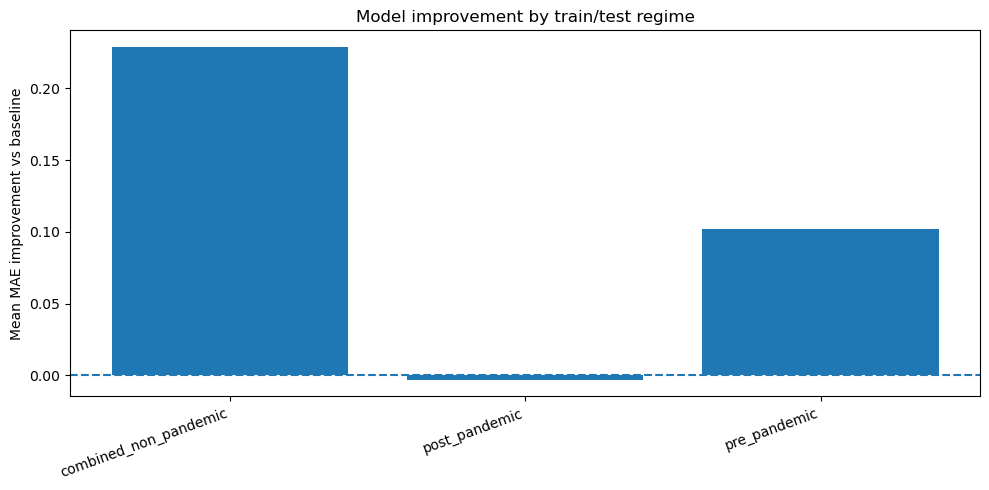

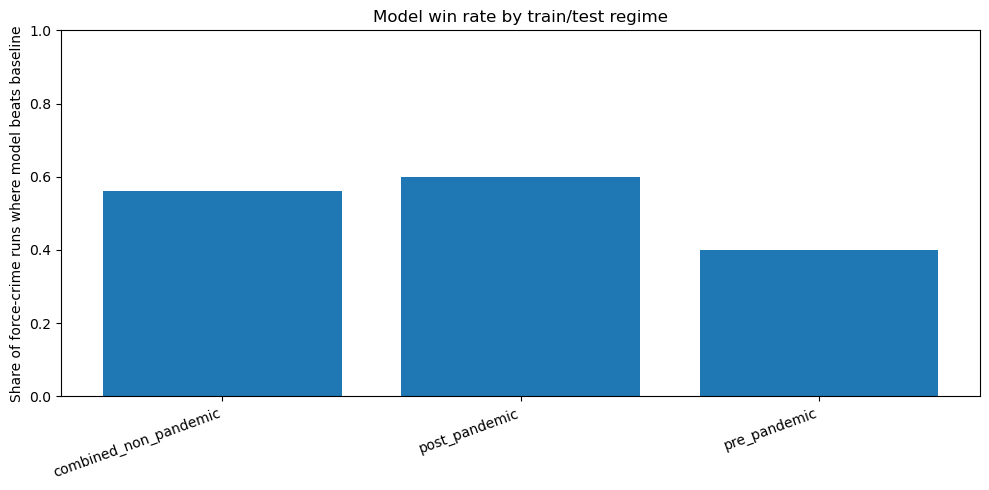

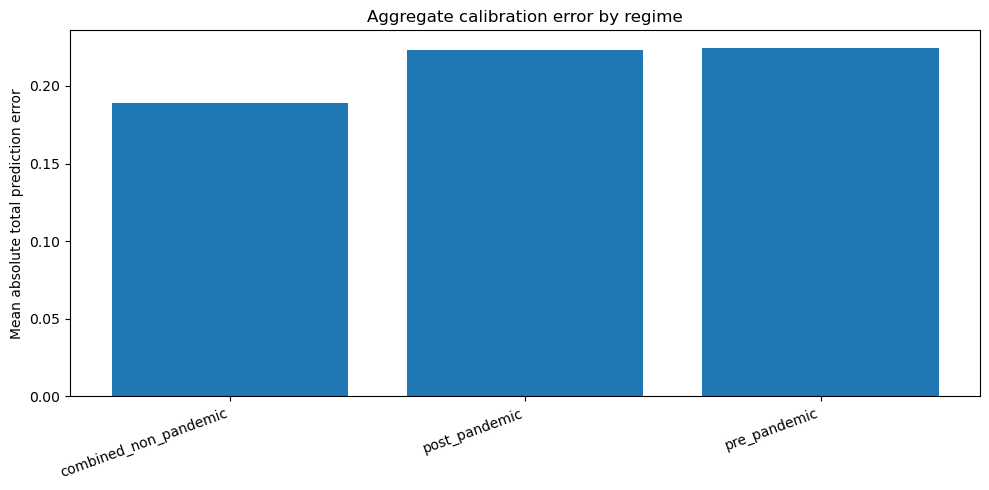

In [20]:
if not evaluated.empty:
    plot_df = experiment_summary.sort_values("experiment_id")

    plt.figure(figsize=(10, 5))
    plt.bar(plot_df["experiment_id"], plot_df["mean_mae_improvement"])
    plt.axhline(0, linestyle="--")
    plt.ylabel("Mean MAE improvement vs baseline")
    plt.title("Model improvement by train/test regime")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(plot_df["experiment_id"], plot_df["model_win_rate"])
    plt.ylim(0, 1)
    plt.ylabel("Share of force-crime runs where model beats baseline")
    plt.title("Model win rate by train/test regime")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(plot_df["experiment_id"], plot_df["mean_abs_total_pct_error"])
    plt.ylabel("Mean absolute total prediction error")
    plt.title("Aggregate calibration error by regime")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()


In [22]:
if not evaluated.empty:
    compact = evaluated.copy()

    alias_map = {
        "mae_improvement_vs_baseline": "mae_improvement",
        "rmae_vs_baseline": "rmae",
        "rmse_improvement_vs_baseline": "rmse_improvement",
        "runtime_seconds": "runtime_s",
        "model_abs_total_pct_error": "abs_total_pct_error",
        "model_total_pct_error": "total_pct_error",
    }

    for old, new in alias_map.items():
        if old in compact.columns and new not in compact.columns:
            compact[new] = compact[old]

    if "mae_improvement" not in compact.columns and {"baseline_mae", "model_mae"}.issubset(compact.columns):
        compact["mae_improvement"] = compact["baseline_mae"] - compact["model_mae"]

    if "rmae" not in compact.columns and {"baseline_mae", "model_mae"}.issubset(compact.columns):
        compact["rmae"] = compact["model_mae"] / compact["baseline_mae"]

    if "rmse_improvement" not in compact.columns and {"baseline_rmse", "model_rmse"}.issubset(compact.columns):
        compact["rmse_improvement"] = compact["baseline_rmse"] - compact["model_rmse"]

    if "abs_total_pct_error" not in compact.columns:
        compact["abs_total_pct_error"] = np.nan

    display_cols = [
        "experiment_id",
        "police_force",
        "crime_type",
        "baseline_mae",
        "model_mae",
        "mae_improvement",
        "rmae",
        "baseline_rmse",
        "model_rmse",
        "rmse_improvement",
        "abs_total_pct_error",
        "coverage_90",
        "winner_mae",
        "max_r_hat",
        "min_ess_bulk",
        "n_divergences",
    ]

    display_cols = [c for c in display_cols if c in compact.columns]

    compact = compact[display_cols].copy()

    round_cols = [
        "baseline_mae",
        "model_mae",
        "mae_improvement",
        "rmae",
        "baseline_rmse",
        "model_rmse",
        "rmse_improvement",
        "abs_total_pct_error",
        "coverage_90",
        "max_r_hat",
    ]

    for col in round_cols:
        if col in compact.columns:
            compact[col] = compact[col].round(3)

    sort_cols = [c for c in ["experiment_id", "police_force", "crime_type"] if c in compact.columns]

    display(compact.sort_values(sort_cols))
else:
    print("No evaluated experiments available yet.")

,experiment_id,police_force,crime_type,baseline_mae,model_mae,mae_improvement,rmae,baseline_rmse,model_rmse,rmse_improvement,abs_total_pct_error,coverage_90,winner_mae,max_r_hat,min_ess_bulk,n_divergences
50,combined_non_pandemic,Cheshire Constabulary,Anti-social behaviour,3.938,1.213,2.726,0.308,4.641,1.489,3.152,0.318,0.978,Bayesian NB adjacency,1.11,18.0,0
51,combined_non_pandemic,Cheshire Constabulary,Criminal damage and arson,1.170,0.996,0.174,0.852,1.401,1.239,0.162,0.222,0.986,Bayesian NB adjacency,1.04,74.0,0
52,combined_non_pandemic,Cheshire Constabulary,Drugs,0.901,0.852,0.050,0.945,1.380,1.228,0.152,0.152,0.963,Bayesian NB adjacency,1.02,53.0,0
53,combined_non_pandemic,Cheshire Constabulary,Possession of weapons,0.340,0.441,-0.101,1.298,0.560,0.549,0.011,0.306,0.995,LSOA mean baseline,1.01,141.0,0
54,combined_non_pandemic,Cheshire Constabulary,Vehicle crime,0.753,0.668,0.085,0.887,0.911,0.834,0.077,0.077,0.975,Bayesian NB adjacency,1.04,68.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,pre_pandemic,West Midlands Police,Anti-social behaviour,2.300,1.572,0.728,0.683,2.771,1.938,0.833,0.146,0.955,Bayesian NB adjacency,1.11,16.0,0
21,pre_pandemic,West Midlands Police,Criminal damage and arson,1.222,1.245,-0.022,1.018,1.536,1.547,-0.011,0.084,0.980,LSOA mean baseline,1.04,44.0,0
22,pre_pandemic,West Midlands Police,Drugs,0.809,0.841,-0.032,1.040,1.059,1.174,-0.115,0.304,0.941,LSOA mean baseline,1.01,156.0,0
23,pre_pandemic,West Midlands Police,Possession of weapons,0.526,0.608,-0.082,1.156,0.796,0.757,0.039,0.257,0.988,LSOA mean baseline,1.03,110.0,0


In [23]:
if SAVE_RESULTS:
    results_path = TABLES_DIR / f"{OUTPUT_TAG}_metrics.csv"
    results_df.to_csv(results_path, index=False)
    print("Saved metrics:", results_path)

    if prediction_outputs:
        predictions_all = pd.concat(prediction_outputs, ignore_index=True)
        predictions_path = TABLES_DIR / f"{OUTPUT_TAG}_predictions.csv"
        predictions_all.to_csv(predictions_path, index=False)
        print("Saved predictions:", predictions_path)
    else:
        predictions_all = pd.DataFrame()
else:
    predictions_all = pd.concat(prediction_outputs, ignore_index=True) if prediction_outputs else pd.DataFrame()

print("Prediction rows:", len(predictions_all))
if not predictions_all.empty:
    display(predictions_all.head(10))


Saved metrics: C:\Users\Alejandro\Desktop\Uni Files\cbl_crime\cbl_20\outputs\tables\shared_regime_comparison_bayesian_adj_no_offset_metrics.csv
Saved predictions: C:\Users\Alejandro\Desktop\Uni Files\cbl_crime\cbl_20\outputs\tables\shared_regime_comparison_bayesian_adj_no_offset_predictions.csv
Prediction rows: 120000


,experiment_id,police_force,crime_type,lsoa_code,lsoa_name,month,observed_count,predicted_count,lower_ci,upper_ci,baseline_predicted_count,neighbour_prev_month_count,neighbour_prev_month_scaled,prev_month_count
0,pre_pandemic,Cheshire Constabulary,Anti-social behaviour,E01012367,Halton 007A,2019-01-01,8,9.965000,5.0,16.00,14.821429,4.0,-1.213250,15.0
1,pre_pandemic,Cheshire Constabulary,Anti-social behaviour,E01012367,Halton 007A,2019-02-01,7,9.556667,5.0,16.00,14.821429,4.6,-0.992912,8.0
2,pre_pandemic,Cheshire Constabulary,Anti-social behaviour,E01012367,Halton 007A,2019-03-01,10,11.038333,6.0,17.05,14.821429,5.6,-0.625682,7.0
3,pre_pandemic,Cheshire Constabulary,Anti-social behaviour,E01012367,Halton 007A,2019-04-01,12,10.831667,6.0,16.00,14.821429,4.8,-0.919466,10.0
4,pre_pandemic,Cheshire Constabulary,Anti-social behaviour,E01012367,Halton 007A,2019-05-01,3,11.000000,6.0,17.00,14.821429,5.8,-0.552236,12.0
5,pre_pandemic,Cheshire Constabulary,Anti-social behaviour,E01012367,Halton 007A,2019-06-01,9,11.588333,6.0,18.00,14.821429,6.8,-0.185005,3.0
6,pre_pandemic,Cheshire Constabulary,Anti-social behaviour,E01012367,Halton 007A,2019-07-01,12,11.978333,6.0,19.00,14.821429,4.8,-0.919466,9.0
7,pre_pandemic,Cheshire Constabulary,Anti-social behaviour,E01012367,Halton 007A,2019-08-01,12,11.510000,6.0,19.00,14.821429,5.4,-0.699128,12.0
8,pre_pandemic,Cheshire Constabulary,Anti-social behaviour,E01012367,Halton 007A,2019-09-01,15,10.581667,5.0,17.00,14.821429,5.4,-0.699128,12.0
9,pre_pandemic,Cheshire Constabulary,Anti-social behaviour,E01012367,Halton 007A,2019-10-01,12,11.033333,6.0,17.00,14.821429,6.6,-0.258451,15.0
